<a href="https://www.kaggle.com/code/robiulhasanjisan/ai-real-comparison?scriptVersionId=307437698" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-41.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-48.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-25.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-45.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-20.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-4.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-38.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-46.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-26.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/an

In [23]:
!pip install timm albumentations

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import cv2
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

#   IMPORTS

In [53]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np

# Import specific models and their required preprocessing functions
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50V2
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as res_preprocess
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
import numpy as np
import tensorflow as tf



import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


#  SETTINGS

In [54]:

DATASET_PATH = "/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 10 
SEED = 42 # For reproducible train/val splits

# Improved Splitting

In [55]:


print("Loading Training Data...")
train_ds_raw = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print("Loading Validation Data...")
val_ds_raw = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Loading Training Data...
Found 995 files belonging to 2 classes.
Using 796 files for training.
Loading Validation Data...
Found 995 files belonging to 2 classes.
Using 199 files for validation.


#  DATA AUGMENTATION

In [56]:


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Apply augmentation only to training data
train_ds_aug = train_ds_raw.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)


#  MODEL DICTIONARY TO COMPARE

In [58]:


# Format: "Model Name": (Model Class, Preprocessing Function)
models_to_try = {
    "MobileNetV2": (MobileNetV2, mob_preprocess),
    "ResNet50V2": (ResNet50V2, res_preprocess),
    "EfficientNetB0": (EfficientNetB0, eff_preprocess)
}

results = {}

#  COMPARISON LOOP

In [59]:

for model_name, (ModelClass, preprocess_fn) in models_to_try.items():
    
    print(f" Training & Evaluating: {model_name}")
   
    
    # 1. Apply Model-Specific Preprocessing
    train_ds = train_ds_aug.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds_raw.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    # 2. Build Model
    base_model = ModelClass(include_top=False, input_shape=(224, 224, 3), weights="imagenet")
    base_model.trainable = False  # Freeze base model for feature extraction

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid') 
    ])

    # 3. Compile
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # 4. Callbacks (Save best weights for each model)
    model_path = f"best_model_{model_name}.h5"
    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # 5. Train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stop],
        verbose=1 # Change to 2 if you want less console spam
    )

    # 6. Evaluate
    loss, acc = model.evaluate(val_ds, verbose=0)
    print(f" {model_name} Final Validation Accuracy: {acc:.4f}")
    
    # Store results
    results[model_name] = acc

 Training & Evaluating: MobileNetV2
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.7473 - loss: 0.6379

25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 706ms/step - accuracy: 0.7506 - loss: 0.6305 - val_accuracy: 0.9397 - val_loss: 0.2391
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9343 - loss: 0.1698 - val_accuracy: 0.9397 - val_loss: 0.1923
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 304ms/step - accuracy: 0.9541 - loss: 0.1257 - val_accuracy: 0.9246 - val_loss: 0.1997
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 307ms/step - accuracy: 0.9610 - loss: 0.1061 - val_accuracy: 0.9246 - val_loss: 0.1881
 MobileNetV2 Final Validation Accuracy: 0.9397
 Training & Evaluating: ResNet50V2
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7477 - loss: 0.5508

25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 621ms/step - accuracy: 0.7511 - loss: 0.5450 - val_accuracy: 0.9146 - val_loss: 0.2179
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 313ms/step - accuracy: 0.9390 - loss: 0.1442 - val_accuracy: 0.9095 - val_loss: 0.2119
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9582 - loss: 0.0943

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 331ms/step - accuracy: 0.9581 - loss: 0.0951 - val_accuracy: 0.9548 - val_loss: 0.1357
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 0.9710 - loss: 0.0705 - val_accuracy: 0.9397 - val_loss: 0.1421
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.9748 - loss: 0.0626 - val_accuracy: 0.9397 - val_loss: 0.1751
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.9813 - loss: 0.0577 - val_accuracy: 0.9246 - val_loss: 0.1742
 ResNet50V2 Final Validation Accuracy: 0.9548
 Training & Evaluating: EfficientNetB0
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.7732 - loss: 0.4542

25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7762 - loss: 0.4498 - val_accuracy: 0.9246 - val_loss: 0.2306
Epoch 2/10
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9564 - loss: 0.1441

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 323ms/step - accuracy: 0.9815 - loss: 0.0844 - val_accuracy: 0.9447 - val_loss: 0.1457
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9794 - loss: 0.0635

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.9794 - loss: 0.0634 - val_accuracy: 0.9548 - val_loss: 0.1255
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9795 - loss: 0.0500

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.9797 - loss: 0.0501 - val_accuracy: 0.9598 - val_loss: 0.1220
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.9939 - loss: 0.0388

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step - accuracy: 0.9937 - loss: 0.0391 - val_accuracy: 0.9648 - val_loss: 0.1182
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9958 - loss: 0.0335 - val_accuracy: 0.9497 - val_loss: 0.1087
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.9839 - loss: 0.0374 - val_accuracy: 0.9548 - val_loss: 0.1108
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9904 - loss: 0.0467

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step - accuracy: 0.9905 - loss: 0.0463 - val_accuracy: 0.9698 - val_loss: 0.0907
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9940 - loss: 0.0239 - val_accuracy: 0.9698 - val_loss: 0.0965
 EfficientNetB0 Final Validation Accuracy: 0.9698


In [60]:




for name, acc in sorted(results.items(), key=lambda item: item, reverse=True):
    print(f"{name}: {acc*100:.2f}% Accuracy")

best_model_name = max(results, key=results.get)
print(f"\n The most accurate model is {best_model_name}!")
print(f"You can now load 'best_model_{best_model_name}.h5' for your predictions.")

ResNet50V2: 95.48% Accuracy
MobileNetV2: 93.97% Accuracy
EfficientNetB0: 96.98% Accuracy

 The most accurate model is EfficientNetB0!
You can now load 'best_model_EfficientNetB0.h5' for your predictions.


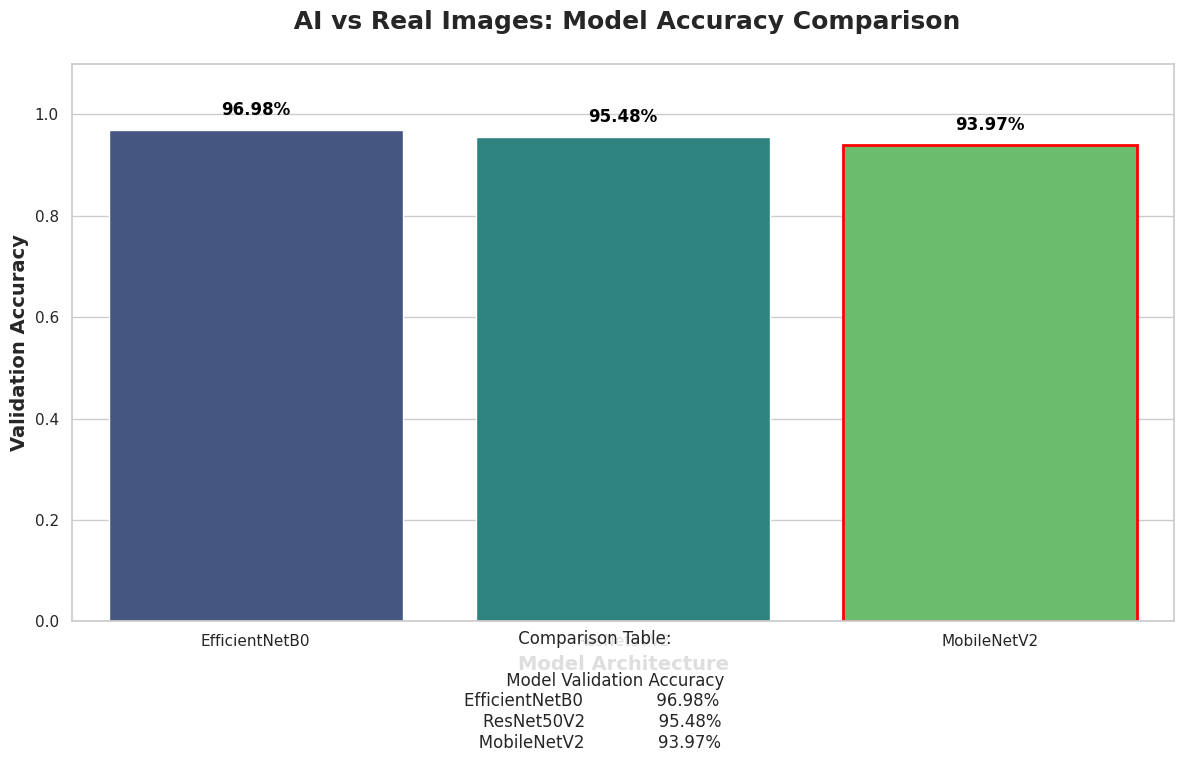

In [61]:


# Convert the results dictionary into a DataFrame
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Validation Accuracy'])
results_df = results_df.sort_values(by='Validation Accuracy', ascending=False)

# Set a visually appealing theme
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(12, 7))

# Barplot with vibrant gradient colors
ax = sns.barplot(
    x='Model', 
    y='Validation Accuracy', 
    data=results_df, 
    palette=sns.color_palette("viridis", len(results_df))
)

# Title and labels
plt.title(' AI vs Real Images: Model Accuracy Comparison', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Model Architecture', fontsize=14, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)

# Show exact accuracy on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black', 
                xytext=(0, 8), textcoords='offset points')

# Optional: highlight the best model with a different edge color
best_idx = results_df['Validation Accuracy'].idxmax()
ax.patches[best_idx].set_edgecolor('red')
ax.patches[best_idx].set_linewidth(2)

# Display a clean, formatted table below the chart
table_text = results_df.to_string(index=False, formatters={'Validation Accuracy': '{:.2%}'.format})
plt.figtext(0.5, -0.08, f" Comparison Table:\n\n{table_text}", 
            ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.85, "pad":5})

# Adjust layout
plt.tight_layout()

# Save and show
plt.savefig('enhanced_model_comparison_accuracy.png', bbox_inches='tight', dpi=300)

plt.show()

                      precision    recall  f1-score   support

Ai_generated_dataset       0.94      0.94      0.94        53
        real_dataset       0.98      0.98      0.98       146

            accuracy                           0.97       199
           macro avg       0.96      0.96      0.96       199
        weighted avg       0.97      0.97      0.97       199



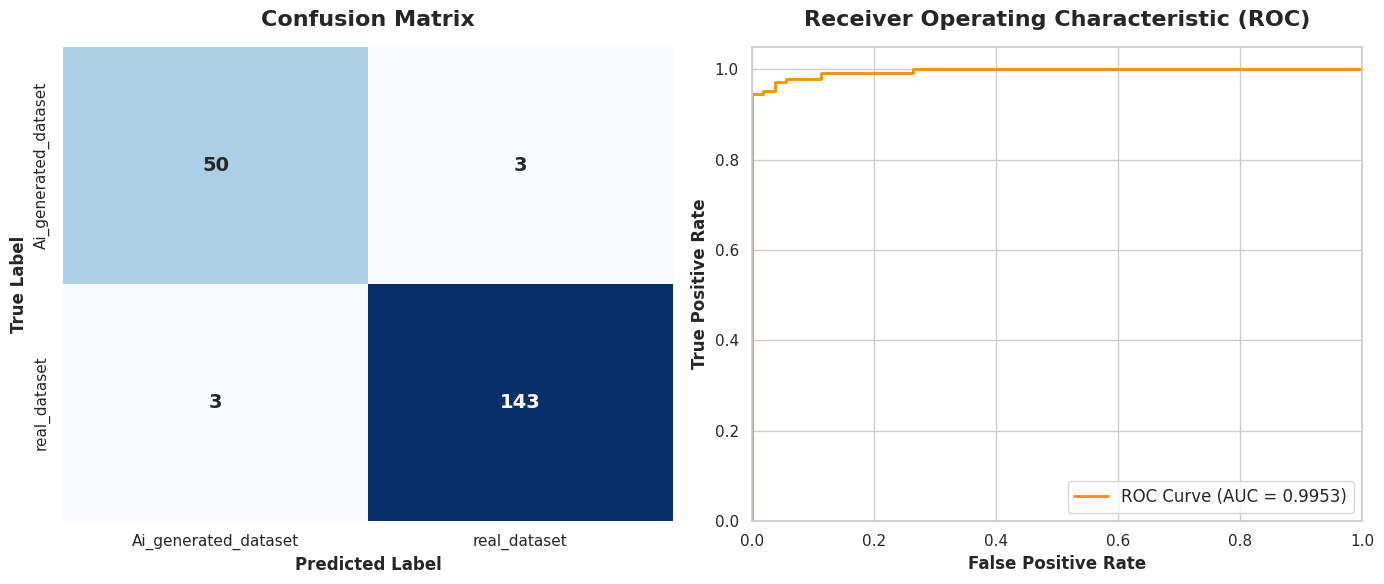

In [65]:



# EXTRACT TRUE LABELS AND PREDICTIONS FROM THE DATASET



y_true = []
y_pred_probs = []

# Loop through the dataset batch by batch
for images, labels in val_ds: 
    y_true.extend(labels.numpy())
    
    # Get probabilities (values between 0 and 1)
    batch_preds = model.predict(images, verbose=0)
    y_pred_probs.extend(batch_preds)

# Convert lists to numpy arrays
y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()

# Convert probabilities to binary classes (0 or 1) using a 0.5 threshold
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Class names (Double check your folder alphabetical order. Usually 0=AI, 1=Real or vice versa)
class_names = val_ds_raw.class_names 


#  CLASSIFICATION REPORT (Precision, Recall, F1-Score)


# This prints the exact metrics you need to copy-paste into your paper's data tables
print(classification_report(y_true, y_pred_classes, target_names=class_names))


plt.figure(figsize=(14, 6))

# Subplot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')


plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')

plt.plot( color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12)


plt.tight_layout()
plt.savefig('academic_evaluation_metrics.png', dpi=300, bbox_inches='tight')

plt.show()

Loading best_model_EfficientNetB0.h5...


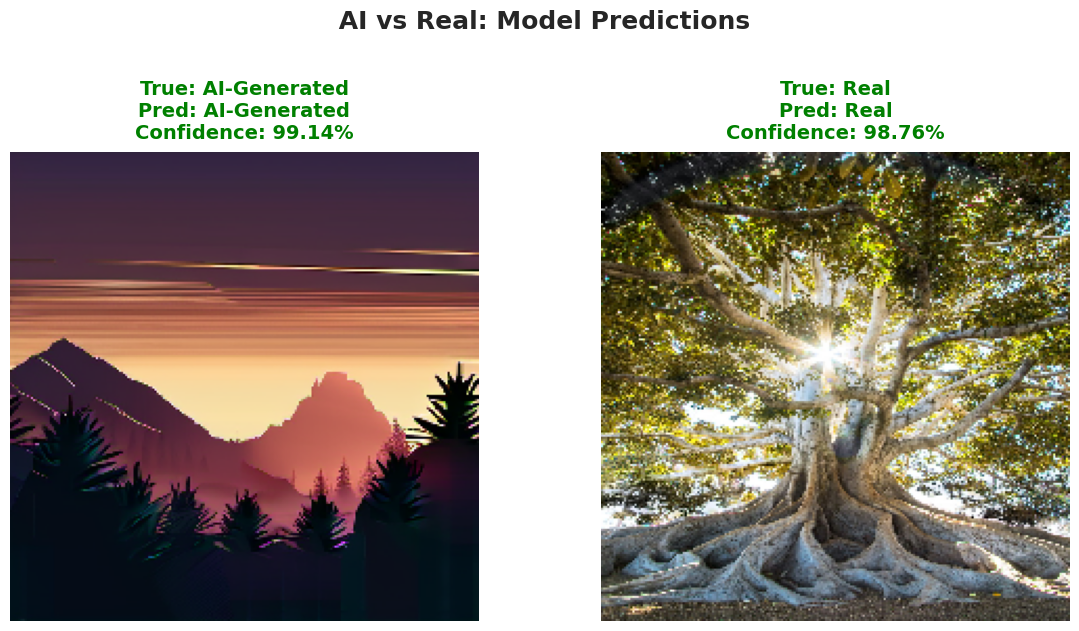

In [74]:

#  TEST THE WINNING MODEL ON RANDOM IMAGES

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# 1. Load the Champion Model
MODEL_PATH = "best_model_EfficientNetB0.h5"
print(f"Loading {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

# 2. Define Dataset Paths
DATASET_PATH = "/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset"

# Helper function to grab a random image from subdirectories
def get_random_image(base_path, keyword):
    all_images = []
    for root, dirs, files in os.walk(base_path):
        if keyword.lower() in root.lower():
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(root, file))
    return random.choice(all_images) if all_images else None

# Grab one random AI image and one random Real image
ai_img_path = get_random_image(DATASET_PATH, "ai_generated")
real_img_path = get_random_image(DATASET_PATH, "real")

# Class mapping (image_dataset_from_directory sorts folders alphabetically by default)
# 0 = Ai_generated_dataset, 1 = real_dataset
CLASS_NAMES = ['AI-Generated', 'Real']

# 3. Prediction & Visualization Function
def predict_and_plot(img_path, ax, true_label):
    if not img_path:
        ax.set_title("Image not found", color='red')
        ax.axis('off')
        return

    # Load and Preprocess Image specifically for EfficientNet
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)

    # Make Prediction
    pred_prob = model.predict(img_preprocessed, verbose=0)
    
    # Determine Class and Confidence
    pred_class_idx = int(pred_prob > 0.5)
    pred_label = CLASS_NAMES[pred_class_idx]
    confidence = float(pred_prob if pred_class_idx == 1 else 1 - pred_prob)  # ✅ Fix here

    # Plot Image
    ax.imshow(img)
    ax.axis('off')
    
    # Text Color: Green if correct, Red if wrong
    is_correct = (true_label == pred_label)
    text_color = 'green' if is_correct else 'red'
    
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}\nConfidence: {confidence*100:.2f}%", 
        fontsize=14, fontweight='bold', color=text_color, pad=10
    )
# 4. Display the Results Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(' AI vs Real: Model Predictions', fontsize=18, fontweight='bold', y=1.05)

# Correctly pass individual axes
predict_and_plot(ai_img_path, axes[0], 'AI-Generated')
predict_and_plot(real_img_path, axes[1], 'Real')

plt.tight_layout()
plt.show()

Loading best_model_EfficientNetB0.h5...


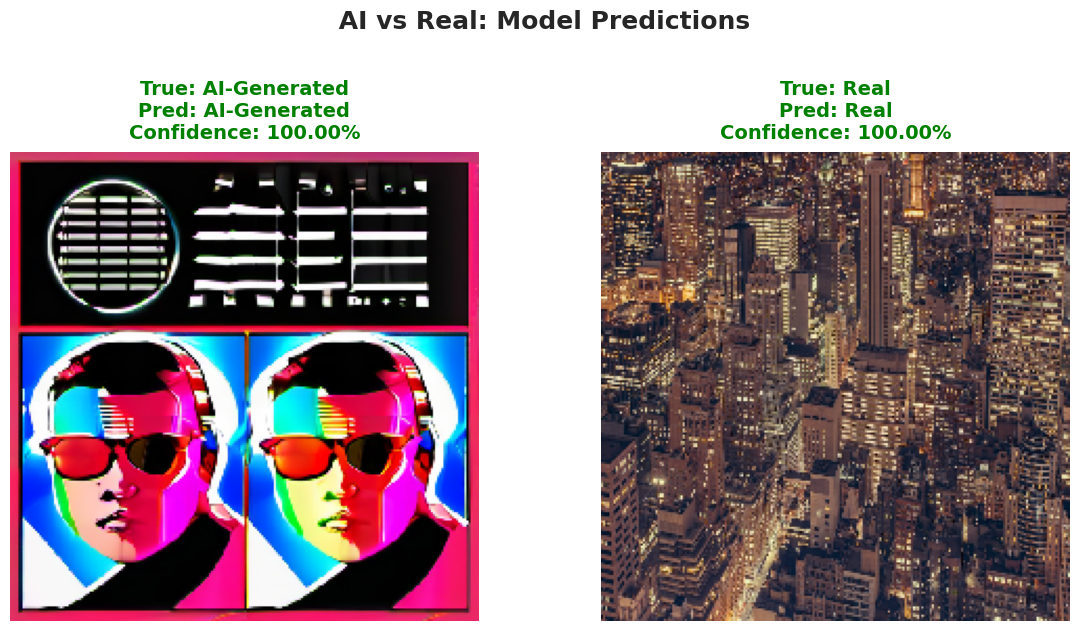

In [75]:

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess


MODEL_PATH = "best_model_EfficientNetB0.h5"
print(f"Loading {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)


DATASET_PATH = "/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset"


def get_random_image(base_path, keyword):
    all_images = []
    for root, dirs, files in os.walk(base_path):
        if keyword.lower() in root.lower():
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(root, file))
    return random.choice(all_images) if all_images else None

# Grab random images
ai_img_path = get_random_image(DATASET_PATH, "ai_generated")
real_img_path = get_random_image(DATASET_PATH, "real")


CLASS_NAMES = ['AI-Generated', 'Real']  # 0 = AI, 1 = Real


def predict_and_plot(img_path, ax, true_label):
    if not img_path:
        ax.set_title("Image not found", color='red')
        ax.axis('off')
        return

    # Load & preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = eff_preprocess(img_batch)

    # Prediction
    pred_prob = model.predict(img_preprocessed, verbose=0)[0][0]  # scalar probability
    pred_class_idx = int(pred_prob > 0.5)
    pred_label = CLASS_NAMES[pred_class_idx]
    confidence = pred_prob if pred_class_idx == 1 else 1 - pred_prob

    # Plot image
    ax.imshow(img_array.astype("uint8"))  
    ax.axis('off')

    # Color: Green if correct, Red if wrong
    is_correct = (true_label == pred_label)
    text_color = 'green' if is_correct else 'red'

    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}\nConfidence: {confidence*100:.2f}%",
        fontsize=14,
        fontweight='bold',
        color=text_color,
        pad=10
    )


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(' AI vs Real: Model Predictions', fontsize=18, fontweight='bold', y=1.05)

# Predict & plot each image
predict_and_plot(ai_img_path, axes[0], 'AI-Generated')
predict_and_plot(real_img_path, axes[1], 'Real')

plt.tight_layout()
plt.show()

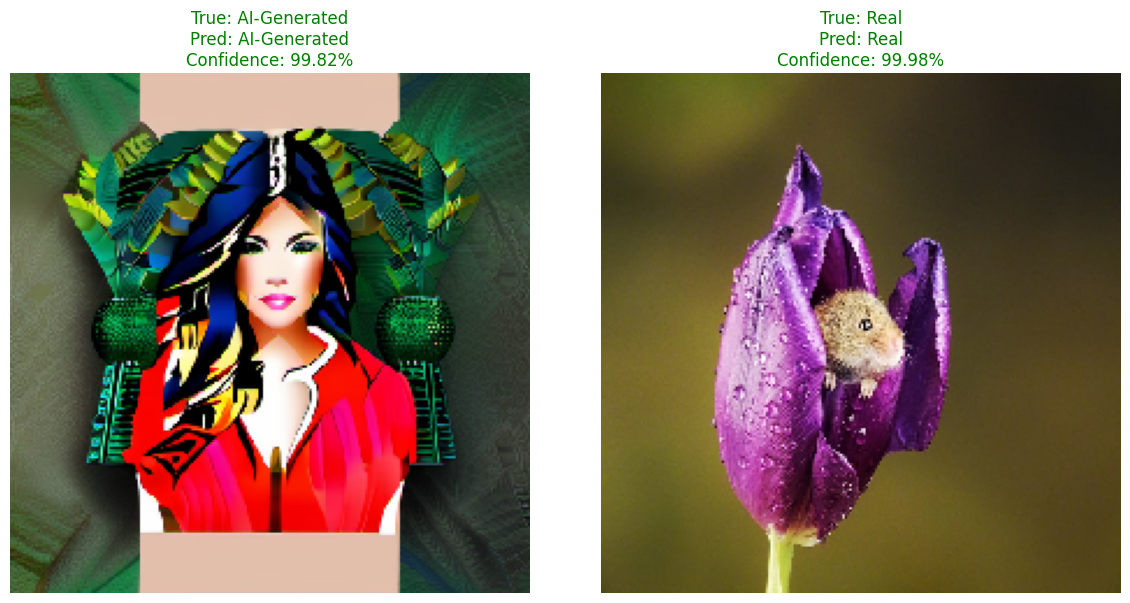

In [76]:


# Load model
MODEL_PATH = "best_model_EfficientNetB0.h5"
model = tf.keras.models.load_model(MODEL_PATH)

# Class names
CLASS_NAMES = ['AI-Generated', 'Real']

# Paths
img_paths = [
    ("/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/people/image-10.png", "AI-Generated"),
    ("/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/real_dataset/animals/animals_103.jpg", "Real")
]

# Function to predict and plot
def predict_and_plot(img_path, true_label, ax):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = eff_preprocess(img_batch)

    pred_prob = model.predict(img_preprocessed, verbose=0)[0][0]
    pred_class_idx = int(pred_prob > 0.5)
    pred_label = CLASS_NAMES[pred_class_idx]
    confidence = pred_prob if pred_class_idx == 1 else 1 - pred_prob

    ax.imshow(img_array.astype("uint8"))
    ax.axis('off')
    text_color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConfidence: {confidence*100:.2f}%", 
                 fontsize=12, color=text_color)

# Plot both images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, (path, label) in enumerate(img_paths):
    predict_and_plot(path, label, axes[i])

plt.tight_layout()
plt.show()